# Manuscript 2 — Figure S3a–e
### Soma volume, and dendritic morphology of projection neurons vs interneurons

**Runs offline — no CAVE access.** Two inputs, both shipped:

| Input | Used by |
| --- | --- |
| `data/lamina1_soma_volumes_15um.csv` | **a** — one row per superficial neuron with its 15 µm-crop soma volume and its cell-class `tag` |
| `data/swc_skeletons/` | **b–e** — `p1`, `p2_cold`, `p2_noci`, `p2_poly` (46 PN) and `lamian_i_in` (interneurons) |

| Panel | Content |
| --- | --- |
| **a** | Soma-volume histogram, interneurons vs projection neurons |
| **b** | Sholl profile (mean ± SEM) in the horizontal plane |
| **c** | All dendritic arbors overlaid, aligned on the soma (rostrocaudal × medial-lateral) |
| **d** | Dendritic territory — convex-hull area of the horizontal projection |
| **e** | Dendritic branch density — branch points per µm of dendrite |

The soma volumes themselves are not recomputed here; `data_generation/` holds the meshing
code that produced the CSV.

## 0) Setup

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from scipy.spatial import ConvexHull
from scipy.stats import mannwhitneyu

DATA_DIR = Path("../data")
SWC_DIR = DATA_DIR / "swc_skeletons"
OUT_DIR = Path("figureS3_outputs")
OUT_DIR.mkdir(exist_ok=True)

CM_TO_INCH = 1 / 2.54
PN_COLOR = "red"
IN_COLOR = "royalblue"

plt.rcParams.update({
    "font.family": "Helvetica",
    "font.size": 7,
    "svg.fonttype": "none",
})

## Figure S3a — soma volume

Volumes come from a 15 µm cube cropped around the soma centroid. Two manual corrections,
both carried over from the original analysis:

- `720575940883198167` — the 15 µm crop clipped this soma, so its 20 µm-crop volume is used.
- `720575940895281326` — a partial reconstruction, excluded outright.

Neurons tagged `o` (partial) are dropped as well. `tag == "p"` are the projection neurons;
everything else is an interneuron.

In [2]:
VOLUME_15UM = "soma_volume_15um_um3"
VOLUME_20UM = "soma_volume_um3"
CORRECT_WITH_20UM_ROOT_ID = "720575940883198167"
EXCLUDE_ROOT_ID = "720575940895281326"

df = pd.read_csv(DATA_DIR / "lamina1_soma_volumes_15um.csv",
                 dtype={"root_id": "string"}, low_memory=False)
df["root_id"] = df["root_id"].astype(str).str.strip()
for col in (VOLUME_15UM, VOLUME_20UM):
    df[col] = pd.to_numeric(df[col], errors="coerce")

mask = df["root_id"] == CORRECT_WITH_20UM_ROOT_ID
assert mask.sum() == 1
old, new = df.loc[mask, VOLUME_15UM].iloc[0], df.loc[mask, VOLUME_20UM].iloc[0]
df.loc[mask, VOLUME_15UM] = new
print(f"Corrected {CORRECT_WITH_20UM_ROOT_ID}: {old:.1f} -> {new:.1f} µm³ using the 20 µm crop.")

df = df[df["root_id"] != EXCLUDE_ROOT_ID].copy()
df["tag"] = df["tag"].fillna("").astype(str).str.strip().str.lower()
df = df[df["tag"] != "o"].copy()                      # drop partial reconstructions
df = df[np.isfinite(df[VOLUME_15UM])].copy()

pn_vol = df.loc[df["tag"] == "p", VOLUME_15UM].astype(float)
in_vol = df.loc[df["tag"] != "p", VOLUME_15UM].astype(float)

print(f"\nProjection neurons: n={len(pn_vol)}, mean={pn_vol.mean():.1f} µm³, SD={pn_vol.std(ddof=1):.1f} µm³")
print(f"Interneurons:       n={len(in_vol)}, mean={in_vol.mean():.1f} µm³, SD={in_vol.std(ddof=1):.1f} µm³")

assert (len(pn_vol), len(in_vol)) == (45, 411)

Corrected 720575940883198167: 14.3 -> 1606.3 µm³ using the 20 µm crop.

Projection neurons: n=45, mean=1800.9 µm³, SD=365.5 µm³
Interneurons:       n=411, mean=787.3 µm³, SD=269.0 µm³


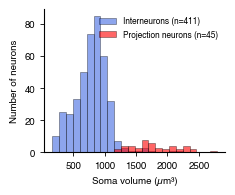

In [3]:
fig, ax = plt.subplots(figsize=(6 * CM_TO_INCH, 5 * CM_TO_INCH))
bins = np.linspace(pd.concat([in_vol, pn_vol]).min(), pd.concat([in_vol, pn_vol]).max(), 25)

ax.hist(in_vol, bins=bins, color=IN_COLOR, alpha=0.6, edgecolor="black", linewidth=0.4,
        label=f"Interneurons (n={len(in_vol)})")
ax.hist(pn_vol, bins=bins, color=PN_COLOR, alpha=0.6, edgecolor="black", linewidth=0.4,
        label=f"Projection neurons (n={len(pn_vol)})")

ax.set_xlabel("Soma volume (µm³)")
ax.set_ylabel("Number of neurons")
ax.legend(frameon=False, fontsize=6)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.tick_params(axis="both", direction="out", length=3, width=0.6)

plt.tight_layout()
fig.savefig(OUT_DIR / "figureS3a_soma_volume_histogram.svg", format="svg",
            bbox_inches="tight", transparent=True)
plt.show()

## 1) Load the dendritic arbors (panels b–e)

Each SWC is centred on its soma and converted from nm to µm. Node `type` follows the SWC
convention: 1 = soma, 2 = axon, 3 = dendrite.

**Interneurons are restricted to those with a labelled axon**, which is what makes the
dendrite separable — for those, `type == 3` is the dendrite. Interneurons without an axon
label are skipped rather than being treated as all-dendrite, because folding their axon into
the "dendrite" inflates every measurement below (it raises the median territory from
20,118 to 28,401 µm²). That leaves **85** interneurons, the number in the published panels.

PNs are handled differently: their exports contain no axon, so every non-soma node is
dendrite.

In [4]:
NM_TO_UM = 1000.0
PN_FOLDERS = ["p1", "p2_cold", "p2_noci", "p2_poly"]
INTERNEURON_FOLDER = "lamian_i_in"
SWC_COLUMNS = ["id", "type", "x", "y", "z", "radius", "parent"]


def read_swc(path):
    return pd.read_csv(path, comment="#", sep=r"\s+", names=SWC_COLUMNS, header=None)


def prepare_dendrite_swc(swc_file, is_pn=False):
    """Soma-centred dendrite of one neuron, in µm. Returns None if the neuron has no
    soma, or (interneurons only) no labelled axon to separate the dendrite from."""
    swc = read_swc(swc_file)

    soma = swc[swc["type"] == 1]
    if len(soma) == 0:
        return None
    soma_xyz = soma[["x", "y", "z"]].mean().values

    process = swc[swc["type"] != 1].copy()

    if is_pn:
        dendrite = process                       # PN exports carry no axon
    else:
        if not (process["type"] == 2).any():
            return None                          # no axon label -> dendrite not separable
        dendrite = process[process["type"] == 3]

    if len(dendrite) == 0:
        return None

    dendrite = dendrite.copy()
    dendrite[["x", "y", "z"]] = (dendrite[["x", "y", "z"]] - soma_xyz) / NM_TO_UM
    return dendrite


def collect_population(folders, is_pn=False):
    neurons = []
    for folder in folders:
        files = sorted((SWC_DIR / folder).glob("*.swc"))
        kept = [d for d in (prepare_dendrite_swc(f, is_pn) for f in files) if d is not None]
        print(f"  {folder}: {len(kept)} kept of {len(files)}")
        neurons += kept
    return neurons


print("Projection neurons:")
pn_neurons = collect_population(PN_FOLDERS, is_pn=True)
print("Interneurons:")
interneuron_neurons = collect_population([INTERNEURON_FOLDER], is_pn=False)

print(f"\nPN n={len(pn_neurons)}, interneuron n={len(interneuron_neurons)}")
assert (len(pn_neurons), len(interneuron_neurons)) == (46, 85)

Projection neurons:
  p1: 6 kept of 6
  p2_cold: 9 kept of 9
  p2_noci: 16 kept of 16
  p2_poly: 15 kept of 15
Interneurons:


  lamian_i_in: 85 kept of 411

PN n=46, interneuron n=85


## Figure S3b — Sholl analysis

Shells are concentric circles at 10–500 µm in 10 µm steps, measured in the **horizontal
(x–z) plane**: distance is `sqrt(x² + z²)` from the soma, so dorsoventral extent does not
contribute. A dendritic segment counts as an intersection at every radius lying between its
two endpoints' distances.

In [5]:
RADII = np.arange(10, 501, 10)


def sholl_profile(dendrite, radii=RADII):
    """Intersections per shell: count parent-child segments that straddle each radius."""
    coords = {int(r.id): np.array([r.x, r.z]) for r in dendrite.itertuples()}
    intersections = np.zeros(len(radii))

    for row in dendrite.itertuples():
        parent = int(row.parent)
        if parent < 0 or parent not in coords:
            continue
        r1 = np.linalg.norm(coords[parent])
        r2 = np.linalg.norm(coords[int(row.id)])
        intersections[(radii >= min(r1, r2)) & (radii <= max(r1, r2))] += 1

    return intersections


def quantify_sholl(dendrite, radii=RADII):
    profile = sholl_profile(dendrite, radii)
    nonzero = np.where(profile > 0)[0]
    return {
        "profile": profile,
        "auc": np.trapezoid(profile, radii),
        "max_radius": radii[nonzero[-1]] if len(nonzero) else 0,
        "peak": profile.max(),
        "peak_radius": radii[profile.argmax()],
    }


def run_population_sholl(neurons, label):
    results = [quantify_sholl(d) for d in neurons]
    summary = pd.DataFrame([{k: r[k] for k in ("auc", "max_radius", "peak", "peak_radius")}
                            for r in results]).assign(group=label)
    return summary, np.array([r["profile"] for r in results])


pn_sholl_df, pn_profiles = run_population_sholl(pn_neurons, "PN")
in_sholl_df, in_profiles = run_population_sholl(interneuron_neurons, "Interneuron")

print("Sholl summary, Mann-Whitney (two-sided):")
for metric in ["auc", "max_radius", "peak", "peak_radius"]:
    _, p = mannwhitneyu(pn_sholl_df[metric], in_sholl_df[metric], alternative="two-sided")
    print(f"  {metric:12s} PN median={pn_sholl_df[metric].median():7.1f}  "
          f"IN median={in_sholl_df[metric].median():7.1f}  p={p:.3e}")

Sholl summary, Mann-Whitney (two-sided):
  auc          PN median= 1722.5  IN median= 1240.0  p=2.297e-05
  max_radius   PN median=  415.0  IN median=  210.0  p=4.628e-13
  peak         PN median=    9.5  IN median=   13.0  p=1.465e-03
  peak_radius  PN median=   95.0  IN median=   50.0  p=5.099e-07


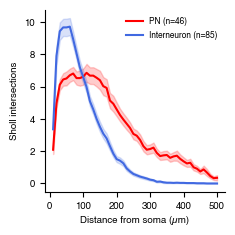

peak of the mean curve: interneuron 9.71 at 60 µm | PN 6.85 at 110 µm


In [6]:
fig, ax = plt.subplots(figsize=(6 * CM_TO_INCH, 6 * CM_TO_INCH))

for profiles, colour, label in [(pn_profiles, PN_COLOR, "PN"),
                                (in_profiles, IN_COLOR, "Interneuron")]:
    mean = profiles.mean(axis=0)
    sem = profiles.std(axis=0) / np.sqrt(len(profiles))
    ax.plot(RADII, mean, color=colour, linewidth=1.5, label=f"{label} (n={len(profiles)})")
    ax.fill_between(RADII, mean - sem, mean + sem, color=colour, alpha=0.2)

ax.set_xlabel("Distance from soma (µm)")
ax.set_ylabel("Sholl intersections")
ax.legend(frameon=False, fontsize=6)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()
fig.savefig(OUT_DIR / "figureS3b_sholl.svg", format="svg", bbox_inches="tight", transparent=True)
plt.show()

print(f"peak of the mean curve: interneuron {in_profiles.mean(0).max():.2f} at "
      f"{RADII[in_profiles.mean(0).argmax()]} µm | PN {pn_profiles.mean(0).max():.2f} at "
      f"{RADII[pn_profiles.mean(0).argmax()]} µm")

## Figure S3c — dendritic arbors overlaid on the soma

Every arbor from both populations, drawn in the horizontal plane with its soma at the
origin. `x` is rostrocaudal and `z` medial-lateral.

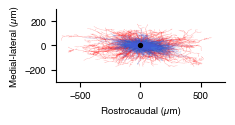

In [7]:
def plot_arbor_xz(dendrite, ax, colour, alpha=0.12, linewidth=0.4):
    """Draw one arbor in the x-z plane, following parent-child edges."""
    coords = {int(r.id): np.array([r.x, r.z]) for r in dendrite.itertuples()}
    for row in dendrite.itertuples():
        parent = int(row.parent)
        if parent < 0 or parent not in coords:
            continue
        p1, p2 = coords[parent], coords[int(row.id)]
        ax.plot([p1[0], p2[0]], [p1[1], p2[1]], color=colour, alpha=alpha, linewidth=linewidth)


fig, ax = plt.subplots(figsize=(6 * CM_TO_INCH, 6 * CM_TO_INCH))

for dendrite in pn_neurons:
    plot_arbor_xz(dendrite, ax, PN_COLOR)
for dendrite in interneuron_neurons:
    plot_arbor_xz(dendrite, ax, IN_COLOR)

ax.scatter(0, 0, color="black", s=8, zorder=5)
ax.set_xlim(-700, 700)
ax.set_ylim(-300, 300)
ax.set_aspect("equal")
ax.set_xlabel("Rostrocaudal (µm)")
ax.set_ylabel("Medial-lateral (µm)")
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()
fig.savefig(OUT_DIR / "figureS3c_arbor_overlay.png", dpi=300, bbox_inches="tight")
plt.show()

## Figure S3d, S3e — dendritic territory and branch density

- **territory** — area of the convex hull of the arbor's nodes projected onto the horizontal
  plane, in µm²
- **branch density** — number of branch points (nodes with more than one child) divided by
  total dendritic path length, in branch points per µm

In [8]:
def quantify_dendrite_morphology(dendrite):
    """Convex-hull area of the horizontal projection, branch points, path length."""
    xyz = dendrite[["x", "y", "z"]].values
    points_xz = np.column_stack([xyz[:, 0], xyz[:, 2]])
    xz_area = ConvexHull(points_xz).volume if len(points_xz) >= 3 else np.nan

    branch_points = int((dendrite["parent"].value_counts() > 1).sum())

    coords = {int(r.id): np.array([r.x, r.y, r.z]) for r in dendrite.itertuples()}
    dendritic_length = sum(
        np.linalg.norm(coords[int(r.id)] - coords[int(r.parent)])
        for r in dendrite.itertuples()
        if int(r.parent) >= 0 and int(r.parent) in coords
    )

    return {
        "xz_area": xz_area,
        "branch_points": branch_points,
        "dendritic_length": dendritic_length,
        "branch_density": branch_points / dendritic_length if dendritic_length > 0 else np.nan,
    }


def analyze_population(neurons, label):
    return pd.DataFrame([{**quantify_dendrite_morphology(d), "group": label} for d in neurons])


pn_morph = analyze_population(pn_neurons, "PN")
in_morph = analyze_population(interneuron_neurons, "Interneuron")

print("Morphology statistics")
print("=====================")
for metric in ["xz_area", "branch_density"]:
    pn_values, in_values = pn_morph[metric].dropna(), in_morph[metric].dropna()
    U, p = mannwhitneyu(pn_values, in_values, alternative="two-sided")
    print(f"\n{metric}")
    print(f"  PN:          n={len(pn_values)}, mean={pn_values.mean():.3f}, "
          f"SD={pn_values.std(ddof=1):.3f}, median={pn_values.median():.3f}")
    print(f"  Interneuron: n={len(in_values)}, mean={in_values.mean():.3f}, "
          f"SD={in_values.std(ddof=1):.3f}, median={in_values.median():.3f}")
    print(f"  Mann-Whitney U={U:.1f}, p={p:.3e}")

Morphology statistics

xz_area
  PN:          n=46, mean=67030.786, SD=26362.631, median=66387.906
  Interneuron: n=85, mean=22724.781, SD=13470.991, median=20117.642
  Mann-Whitney U=3658.0, p=2.226e-16

branch_density
  PN:          n=46, mean=0.011, SD=0.005, median=0.011
  Interneuron: n=85, mean=0.013, SD=0.005, median=0.012
  Mann-Whitney U=1401.0, p=7.610e-03


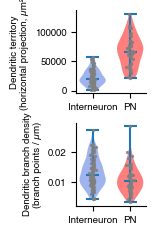

In [9]:
fig, axes = plt.subplots(2, 1, figsize=(4 * CM_TO_INCH, 6 * CM_TO_INCH))

plot_info = [
    ("xz_area", "Dendritic territory\n(horizontal projection, µm²)"),
    ("branch_density", "Dendritic branch density\n(branch points / µm)"),
]

for ax, (metric, ylabel) in zip(axes, plot_info):
    data = [in_morph[metric].dropna(), pn_morph[metric].dropna()]
    violin = ax.violinplot(data, positions=[0, 1], showmedians=True, widths=0.7)
    for body, colour in zip(violin["bodies"], (IN_COLOR, PN_COLOR)):
        body.set_facecolor(colour)
        body.set_alpha(0.5)

    rng = np.random.default_rng(1)   # seeded so the jitter is reproducible
    for i, values in enumerate(data):
        x = np.ones(len(values)) * i + rng.normal(0, 0.04, len(values))
        ax.scatter(x, values, s=2, color="grey", alpha=0.8, zorder=3)

    ax.set_xticks([0, 1])
    ax.set_xticklabels(["Interneuron", "PN"])
    ax.set_ylabel(ylabel)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

plt.tight_layout()
fig.savefig(OUT_DIR / "figureS3de_dendrite_morphology.svg", format="svg",
            bbox_inches="tight", transparent=True)
plt.show()

### Cross-check against the published panels

In [10]:
# values recorded in the original analysis that produced the published figure
for metric, U_pub, p_pub in [("xz_area", 3658.0, 2.226e-16), ("branch_density", 1401.0, 7.610e-03)]:
    U, p = mannwhitneyu(pn_morph[metric].dropna(), in_morph[metric].dropna(), alternative="two-sided")
    assert np.isclose(U, U_pub) and np.isclose(p, p_pub, rtol=1e-3), (metric, U, p)

for metric, pn_pub, in_pub in [("auc", 1722.5, 1240.0), ("max_radius", 415.0, 210.0),
                               ("peak", 9.5, 13.0), ("peak_radius", 95.0, 50.0)]:
    assert np.isclose(pn_sholl_df[metric].median(), pn_pub), metric
    assert np.isclose(in_sholl_df[metric].median(), in_pub), metric

print("All published statistics reproduced:")
print("  n           PN 46, interneuron 85 (soma panel: PN 45, interneuron 411)")
print("  territory   U=3658.0, p=2.226e-16")
print("  branch den. U=1401.0, p=7.610e-03")
print("  Sholl medians (auc / max_radius / peak / peak_radius) all match")

All published statistics reproduced:
  n           PN 46, interneuron 85 (soma panel: PN 45, interneuron 411)
  territory   U=3658.0, p=2.226e-16
  branch den. U=1401.0, p=7.610e-03
  Sholl medians (auc / max_radius / peak / peak_radius) all match
